In [43]:
import os
import sys

import gravis as gv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import BayesianGaussianMixture

# Add the path to the `src` directory to the sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src")))

from nhssynth.modules.dataloader.metadata import MetaData
from nhssynth.modules.dataloader.metatransformer import MetaTransformer
from nhssynth.modules.model.models import VAE

In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We first load in the required parts of the `NHSSynth` package and other packages that we will use in this notebook.

We then load in our dataset and instantiate the `MetaTransformer`:

In [ ]:
dataset = pd.read_csv("../data/support.csv")

In [ ]:
md = MetaData.from_path(dataset, "../data/support_metadata.yaml")
mt = MetaTransformer(dataset, md)
# Note that we could skip loading in the metadata the above two lines in one line:
# mt = MetaTransformer.from_path(dataset, "../data/support_metadata.yaml")

Minimal constraints resolved to:
[x8 < 180, x8 > 0]



/Users/jonathan.pearson/Documents/GitRepos/NHSSynth/src/nhssynth/modules/dataloader/metadata.py:59: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return _guess_datetime_format_for_array(data[data.notna()].astype(str).to_numpy())


We may want to observe the constraints as they are applied by the `MetaTransformer`, this can be done using the `gravis` package:

In [47]:
gv.d3(mt._metadata.constraints.minimal_graph)
# or gv.d3(mt.metadata.constraints.graph)

In [48]:
transformed_dataset = mt.apply()

/Users/jonathan.pearson/Documents/GitRepos/NHSSynth/src/nhssynth/modules/dataloader/transformers/datetime.py:49: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  ns = dt.view("int64").astype("float64")


[datetime.apply] dob: p1=1931-01-22 10:18:50.400000  p99=2000-05-15 02:42:18  Δ≈25315.7 days  clamp=ON  pool=5000
[[-0.88173166 -0.1835644  -0.54389123 -1.67083309 -0.32026935]
 [-0.79910075 -0.09224822 -0.44459809 -1.57093419 -0.27141519]
 [ 0.72562299  1.59273817  1.38758096  0.27242238  0.63005255]
 ...
 [-0.60668459  0.12039267 -0.21338187 -1.3383074  -0.15765231]
 [-0.35375268  0.39991008  0.09055289 -1.03251843 -0.00811049]
 [ 0.28835028  1.10950403  0.86213371 -0.25623045  0.37152228]]
[-0.1835644  -0.09224822  0.27242238 ...  0.12039267  0.09055289
  0.28835028]
      dob_normalised  dob_c1  dob_c2  dob_c3  dob_c4  dob_c5
0          -0.183564     0.0     1.0     0.0     0.0     0.0
1          -0.092248     0.0     1.0     0.0     0.0     0.0
2           0.272422     0.0     0.0     0.0     1.0     0.0
3          -0.078624     1.0     0.0     0.0     0.0     0.0
4          -0.188437     0.0     0.0     1.0     0.0     0.0
...              ...     ...     ...     ...     ...     

In [49]:
print("mt id:", id(mt))

mt id: 5356403664


In [50]:
model = VAE(transformed_dataset, mt)

# Use notebook_run flag to avoid messy output from metric reporting during a run
stats = model.train(notebook_run=True)

/Users/jonathan.pearson/Documents/GitRepos/NHSSynth/.nhssynth/lib/python3.11/site-packages/torch/nn/init.py:452: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")
                                                       

Completed 9 epochs in 8.55 seconds.


In [51]:
print("mt inside VAE:", id(model.metatransformer))   # add this print inside VAE.__init__
assert model.metatransformer is mt


mt inside VAE: 5356403664


In [52]:
synthetic_dataset = model.generate()
synthetic_dataset.describe()

one-hot groups (sizes): []
z std (median over cols): 1.639258861541748
[gen:z-std] x8: std=1.3529
[gen:z-std] dob: std=1.9256
[pre-revert df] x8_normalised: std=1.3529, min=-12.7011, max=-2.3521
[pre-revert df] dob_normalised: std=1.9256, min=-18.9710, max=-4.7727
[dob] scale=4
sigma_floor=571.0560793309298
sigmas(min,max)=2787,5699
decoded_std=2.527e+04
[revert:dob] z_std=1.9256 decoded_std=25246.6672 uniques=8032
[x8] scale=4
sigma_floor=3.160102432407026
sigmas(min,max)=6.038,29.81
decoded_std=152.6
[revert:x8] z_std=1.3529 decoded_std=152.5925 uniques=8033
[post-revert] x8 uniques=8034 min/max=-1189.7222535363294 / 18.02636041157247 | dob min/max=1677-09-25 03:01:05.544836096 / 1827-01-12 09:12:39.207110656
[post-constraints] x8 uniques=8034 min/max=-1189.7222535363294 / 18.02636041157247 | dob min/max=1677-09-25 03:01:05.544836096 / 1827-01-12 09:12:39.207110656
[post-dtypes] x8 uniques=8034 min/max=-1189.7222535363294 / 18.02636041157247 | dob min/max=1677-09-25 03:01:05.54483609

,dob,x8
count,1638,8034.000000
mean,1710-02-17 06:50:39.316239360,-227.634180
min,1677-09-25 03:01:05,-1190.000000
25%,1690-04-25 22:55:08.250000384,-270.000000
50%,1704-02-28 13:24:07.000000512,-203.000000
75%,1725-02-01 06:36:38.499999744,-131.000000
max,1827-01-12 09:12:39,18.000000
std,NaN,152.601837


In [53]:
print("x8 unique:", synthetic_dataset["x8"].nunique(dropna=False))
print("x8 min/max:", synthetic_dataset["x8"].min(), synthetic_dataset["x8"].max())
print("dob min/max:", synthetic_dataset["dob"].min(), synthetic_dataset["dob"].max())


x8 unique: 779
x8 min/max: -1190.0 18.0
dob min/max: 1677-09-25 03:01:05 1827-01-12 09:12:39


In [54]:
mt.typed_dataset.describe()

,dob,x8
count,8009,8034.0
mean,1960-04-19 14:27:16.548882496,97.385487
min,1921-02-25 19:07:00,0.0
25%,1948-11-30 15:28:00,72.0
50%,1958-01-30 11:06:00,100.0
75%,1970-01-06 06:22:00,120.0
max,2004-12-16 07:09:00,300.0
std,NaN,31.602991


In [55]:
synthetic_dataset.head(25)

,dob,x8
0,NaT,-796.0
1,1717-03-04 18:23:32,-25.0
2,1717-04-29 15:23:56,-171.0
3,NaT,-212.0
4,NaT,-611.0
5,NaT,-372.0
6,NaT,-230.0
7,NaT,-208.0
8,NaT,-55.0
9,1732-02-18 04:07:18,-336.0


In [56]:
mt.typed_dataset.head(25)

,dob,x8
0,1940-04-16 19:24:00,55.0
1,1943-05-05 10:27:00,67.0
2,1999-08-08 07:53:00,144.0
3,1969-12-04 09:28:00,100.0
4,1951-03-17 10:07:00,135.0
5,1973-01-25 08:29:00,105.0
6,1960-01-22 13:04:00,130.0
7,1951-07-18 12:30:00,102.0
8,1941-12-20 16:13:00,102.0
9,1955-07-16 15:56:00,75.0


In [57]:
mt.transformed_dataset

,dob_normalised,dob_c1,dob_c2,dob_c3,dob_c4,dob_c5,dob_missing,x8_normalised,x8_c1,x8_c2,x8_c3,x8_c4,x8_c5
0,-0.183564,0,1,0,0,0,0,-0.231519,0,0,0,1,0
1,-0.092248,0,1,0,0,0,0,0.075426,0,0,0,1,0
2,0.272422,0,0,0,1,0,0,0.112388,0,0,1,0,0
3,-0.078624,1,0,0,0,0,0,-0.263676,0,1,0,0,0
4,-0.188437,0,0,1,0,0,0,0.424501,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8029,-0.134297,0,1,0,0,0,0,-0.067054,0,1,0,0,0
8030,0.120393,0,1,0,0,0,0,-0.034433,1,0,0,0,0
8031,0.090553,0,0,1,0,0,0,-0.067054,0,1,0,0,0
8032,0.000000,0,0,0,0,0,1,-0.067054,0,1,0,0,0


In [58]:
print(synthetic_dataset['x8'].min(), synthetic_dataset['x8'].max())
print(synthetic_dataset['dob'].min(), synthetic_dataset['dob'].max())

-1190.0 18.0
1677-09-25 03:01:05 1827-01-12 09:12:39


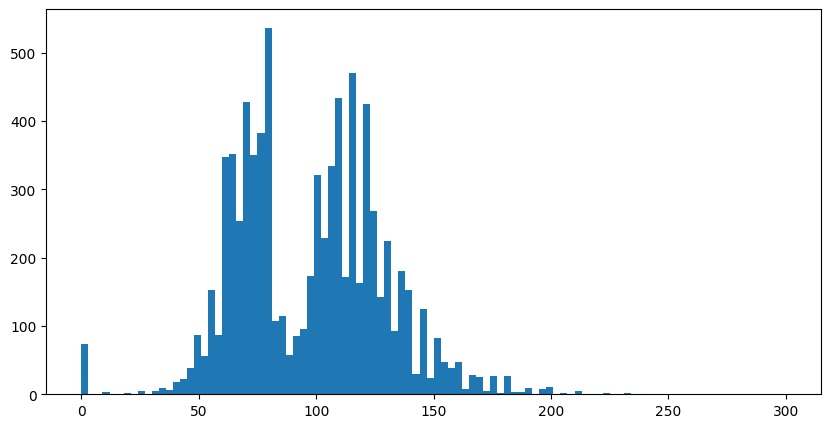

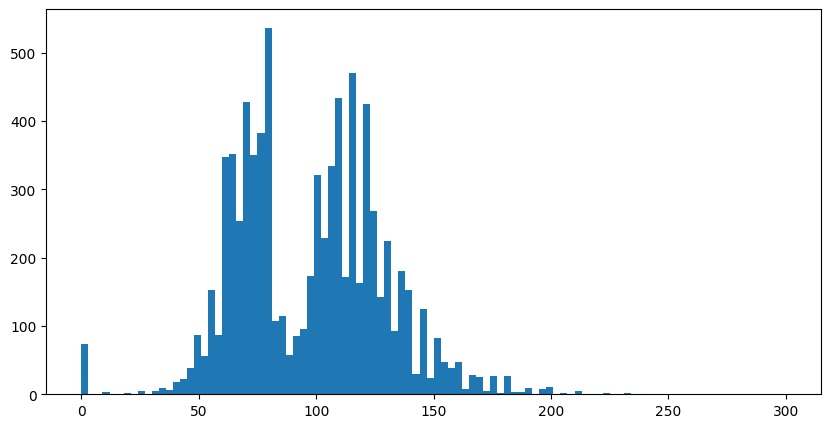

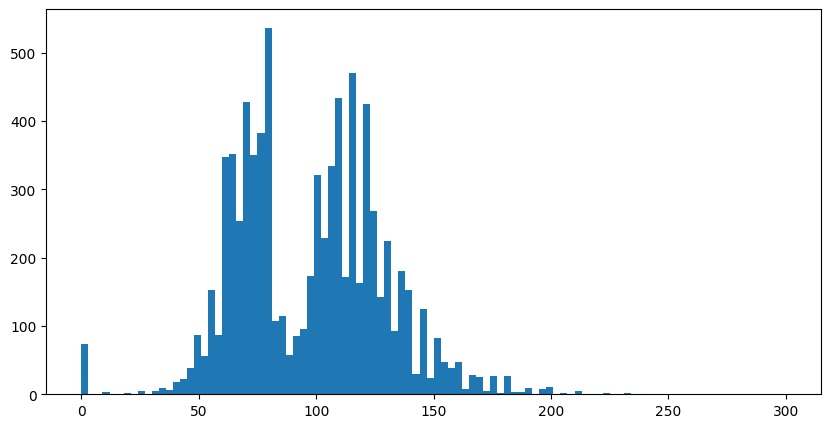

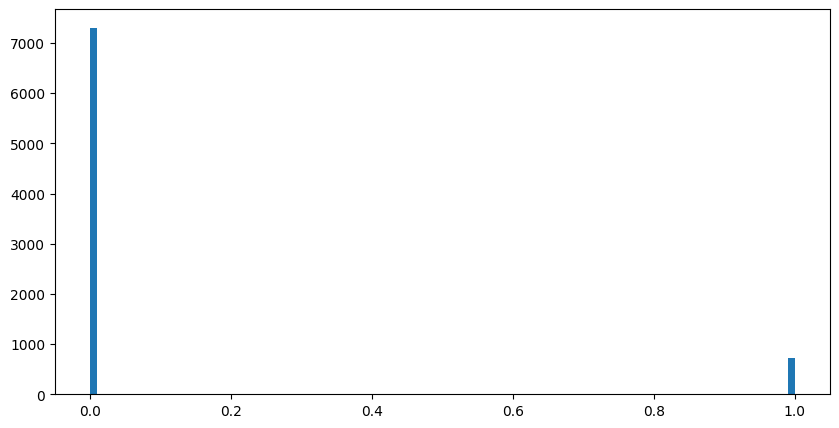

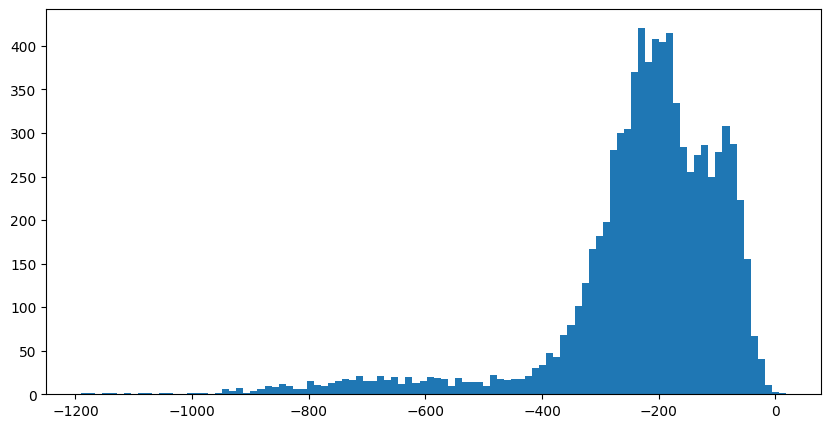

In [59]:
# plot column histogram:
col = "x8"
plt.figure(figsize=(10, 5))
plt.hist(mt.typed_dataset[col][mt.typed_dataset[col].notna()], bins=100)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(
    mt.post_missingness_strategy_dataset[col][
        mt.post_missingness_strategy_dataset[col].notna()
    ],
    bins=100,
)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(mt.constrained_dataset[col][mt.constrained_dataset[col].notna()], bins=100)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(
    mt.transformed_dataset["x8_c3"][mt.transformed_dataset["x8_c3"].notna()], bins=100
)
plt.show()
# plot column histogram of synthetic data:
plt.figure(figsize=(10, 5))
plt.hist(synthetic_dataset[col][synthetic_dataset[col].notna()], bins=100)
plt.show()

n: 8034


/Users/jonathan.pearson/Documents/GitRepos/NHSSynth/.nhssynth/lib/python3.11/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


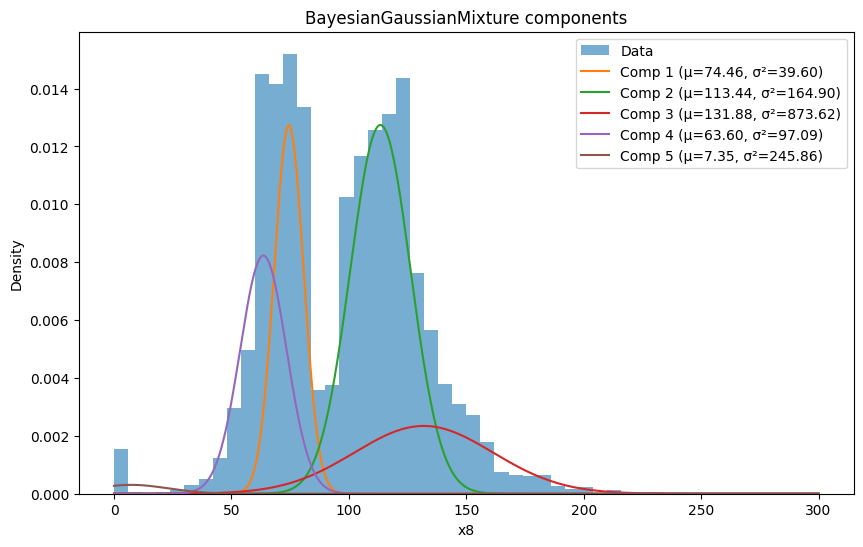

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import BayesianGaussianMixture

# 1) Get data as float, drop NA
s = pd.to_numeric(mt.constrained_dataset[col], errors="coerce")
x1 = s.dropna().to_numpy(dtype=np.float64).reshape(-1, 1)
print("n:", x1.shape[0])

# 2) Fit BGM
model = BayesianGaussianMixture(
    n_components=5,
    covariance_type="full",
    n_init=10,
    random_state=0,
    weight_concentration_prior=1.0,  # good prior to avoid collapse
)
model.fit(x1)

# 3) Plot histogram of data
plt.figure(figsize=(10, 6))
plt.hist(x1.ravel(), bins=50, density=True, alpha=0.6, label="Data")

# 4) Component PDFs
xx = np.linspace(x1.min(), x1.max(), 1000).reshape(-1, 1)

# normal pdf helper
def norm_pdf(x, mean, var):
    return np.exp(-0.5 * ((x - mean) ** 2) / var) / np.sqrt(2 * np.pi * var)

for k in range(model.n_components):
    mu = float(model.means_[k, 0])
    # covariances_ shape depends on cov type; for 1-D 'full' it’s (K, 1, 1)
    cov = model.covariances_
    if cov.ndim == 3:
        var = float(cov[k, 0, 0])
    elif cov.ndim == 2:
        var = float(cov[k, 0])
    else:  # spherical
        var = float(cov[k])
    comp_pdf = model.weights_[k] * norm_pdf(xx, mu, var)
    plt.plot(xx, comp_pdf, label=f"Comp {k+1} (μ={mu:.2f}, σ²={var:.2f})")

plt.xlabel(col)
plt.ylabel("Density")
plt.title("BayesianGaussianMixture components")
plt.legend()
plt.show()
